In [1]:
import matplotlib.pyplot as plt
import numpy as np

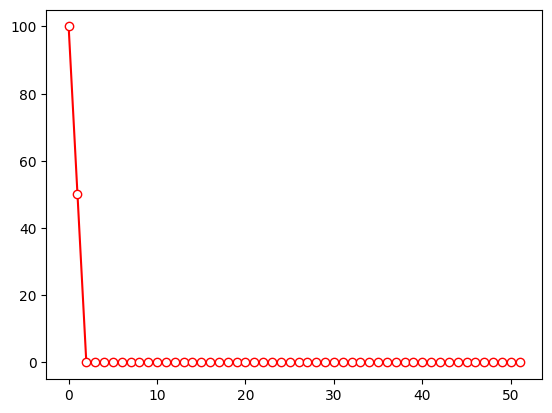

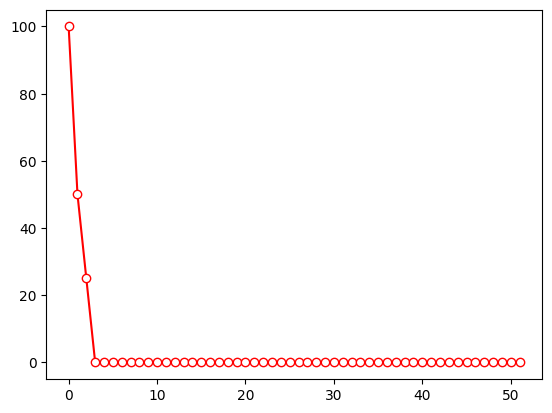

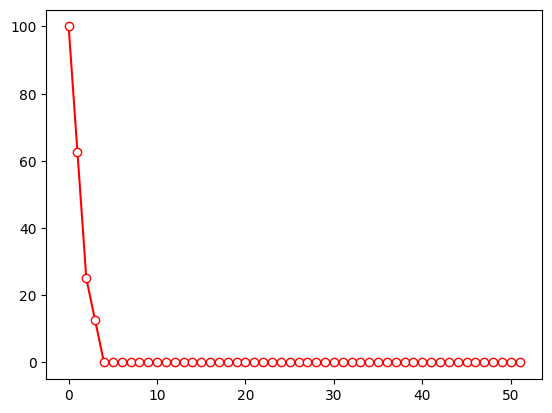

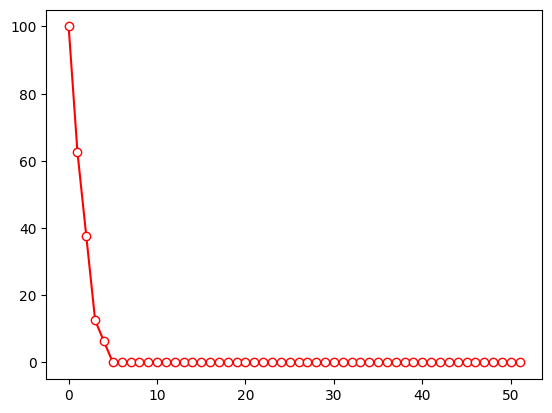

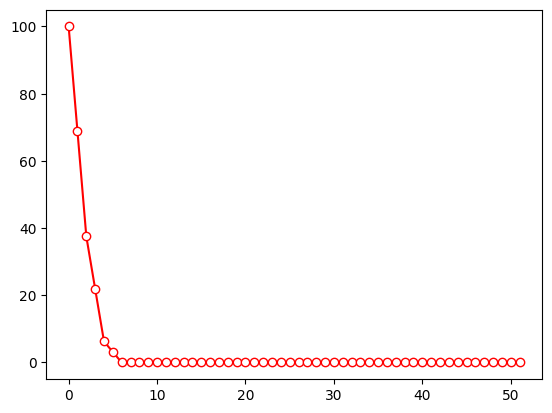

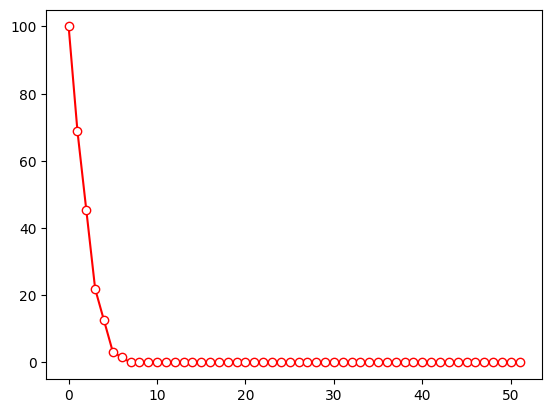

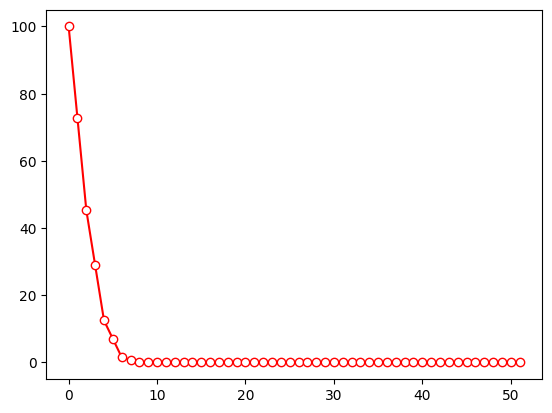

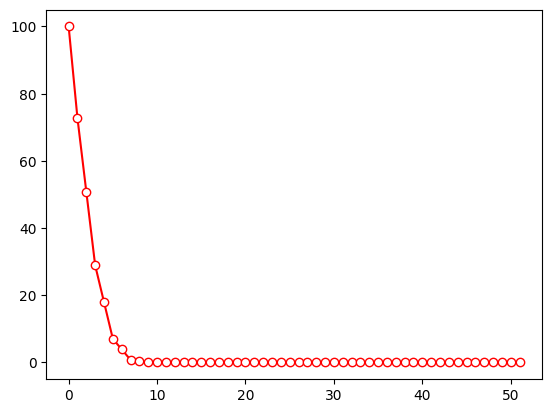

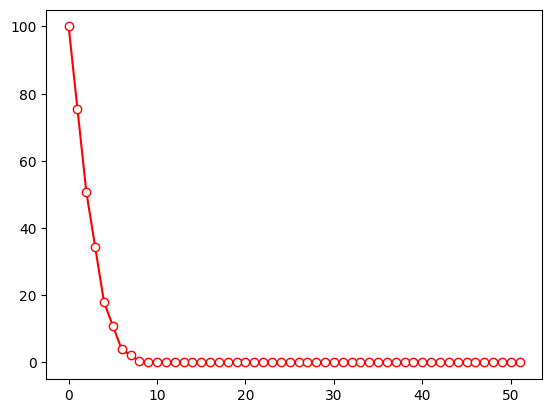

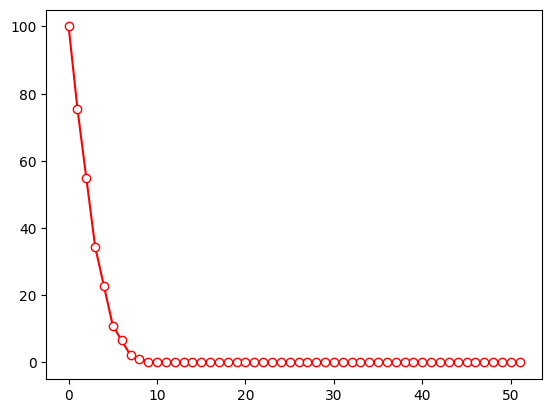

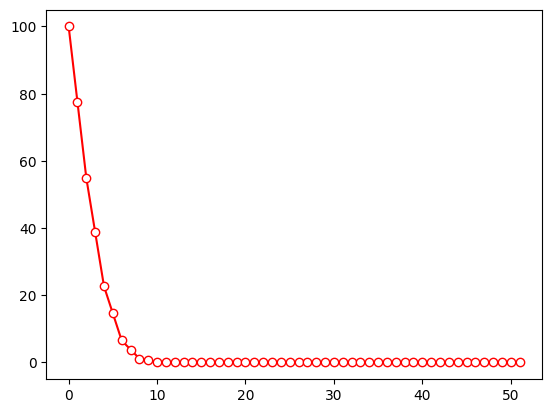

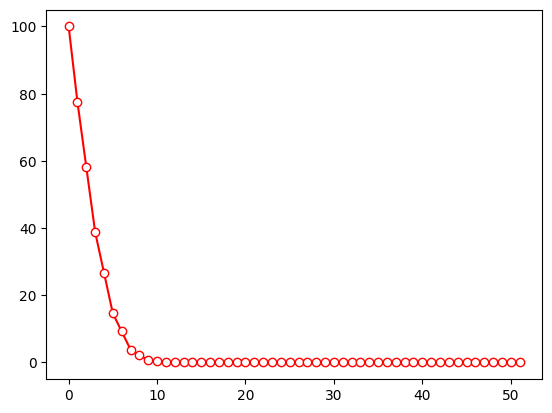

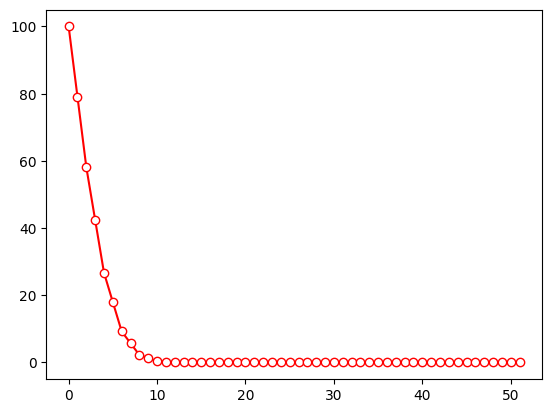

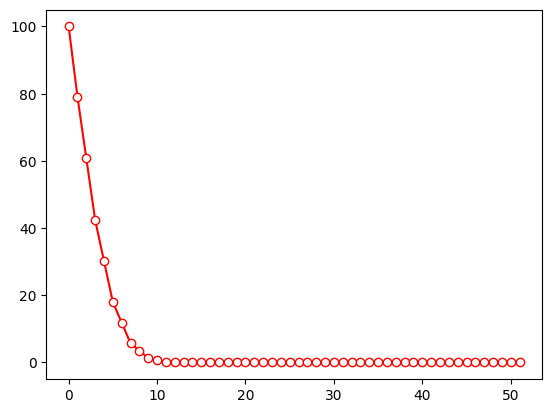

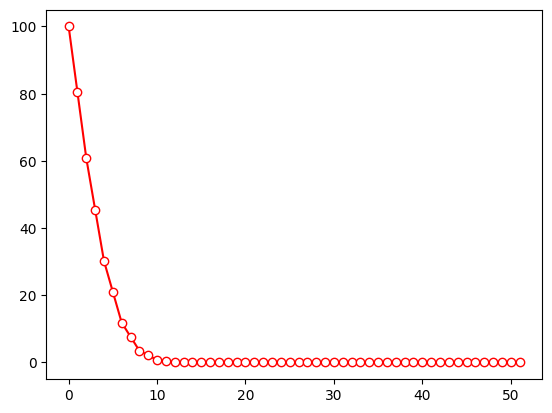

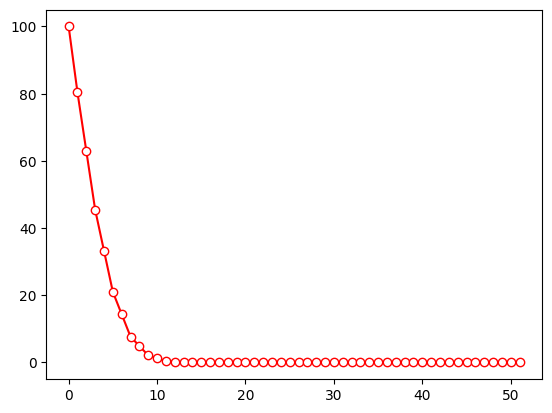

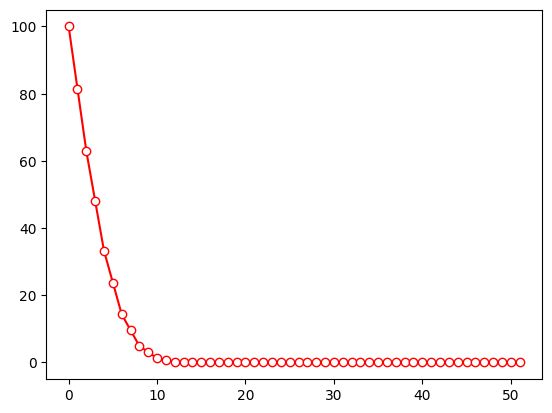

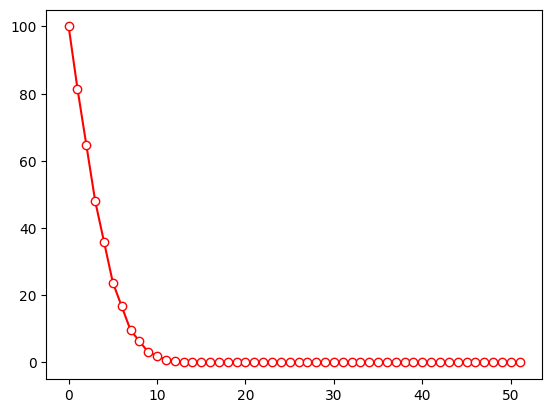

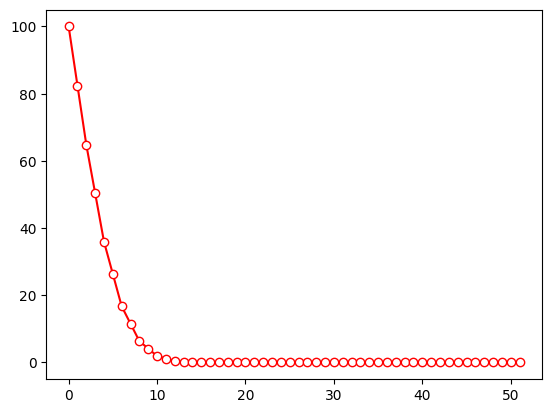

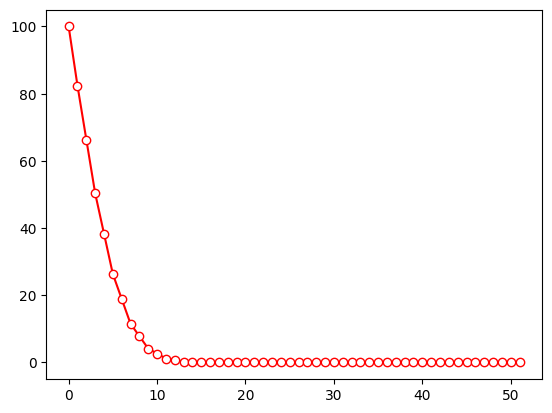

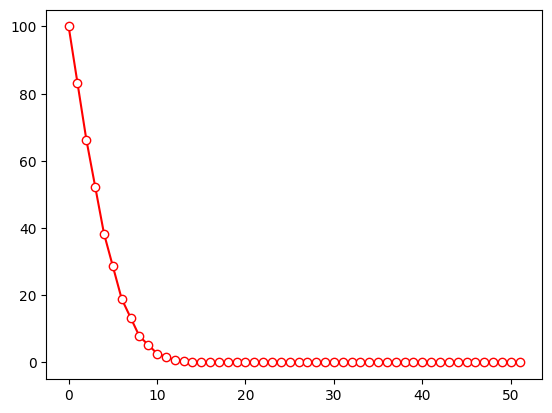

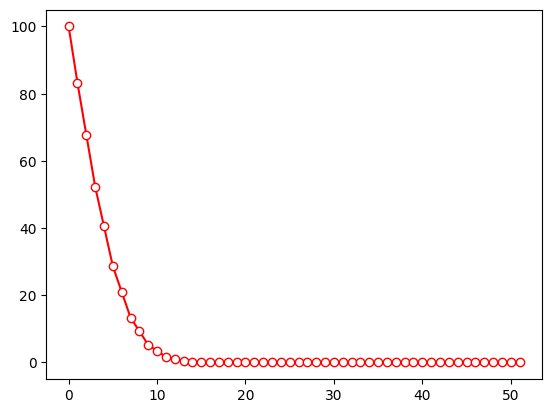

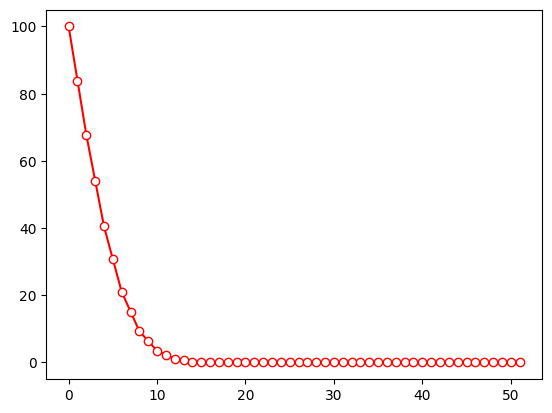

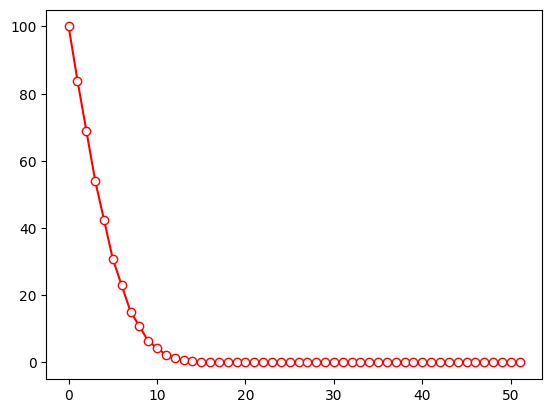

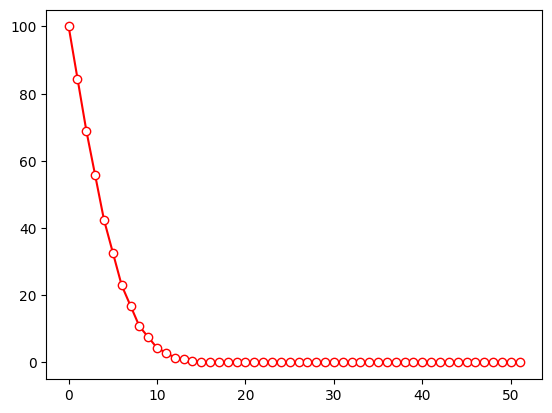

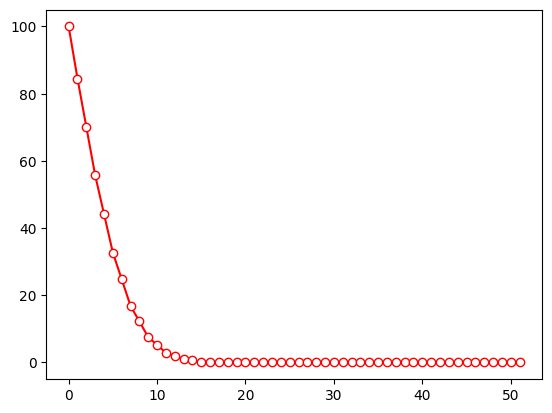

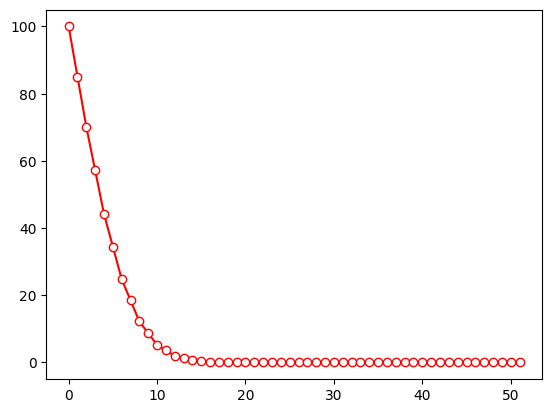

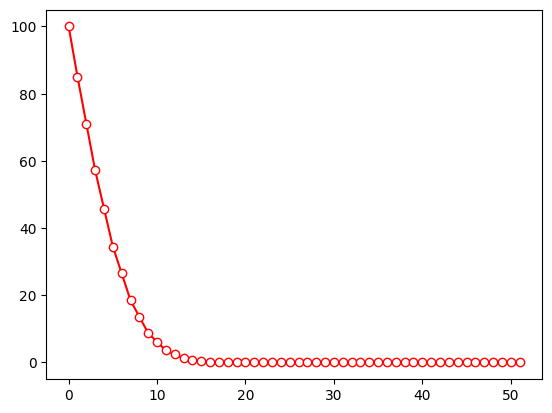

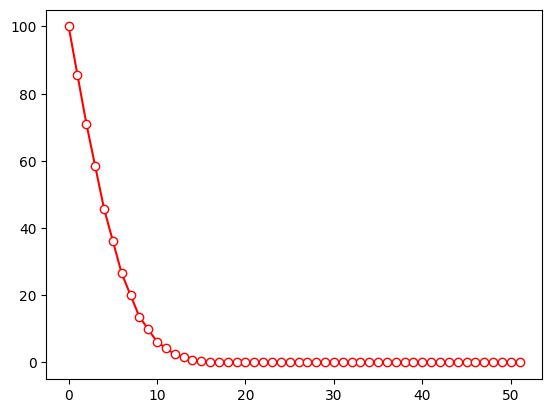

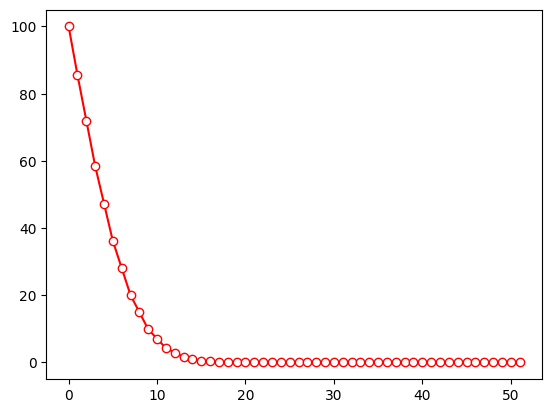

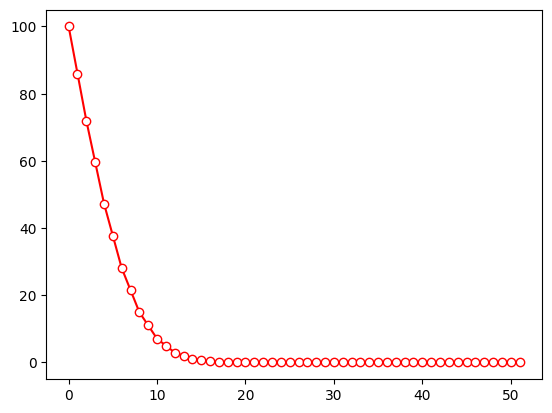

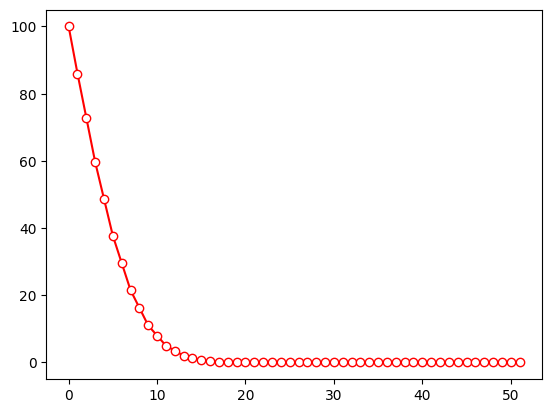

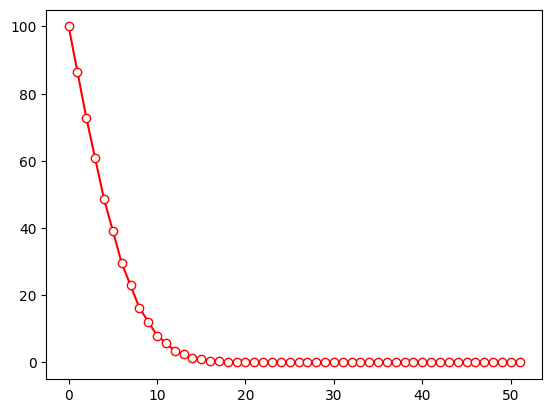

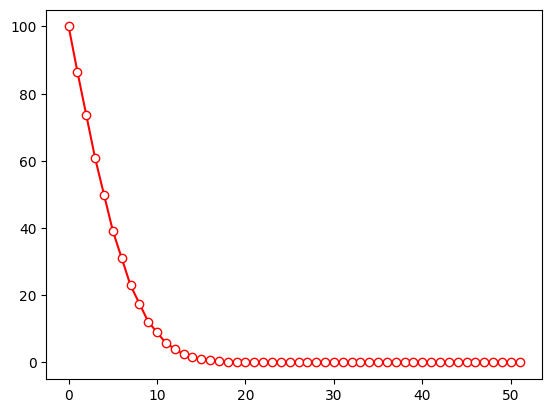

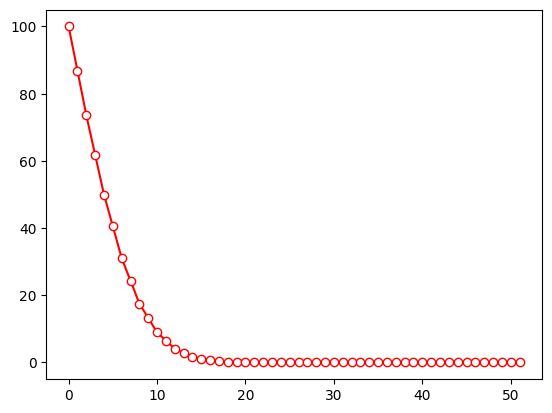

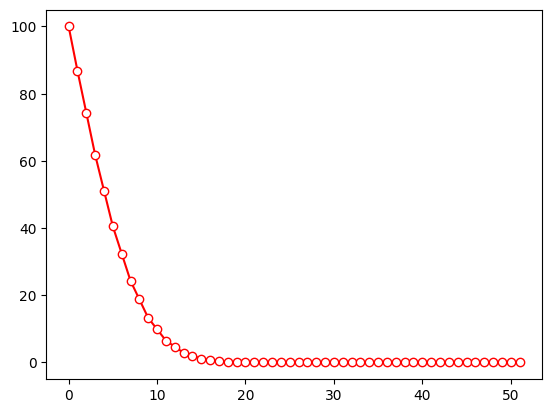

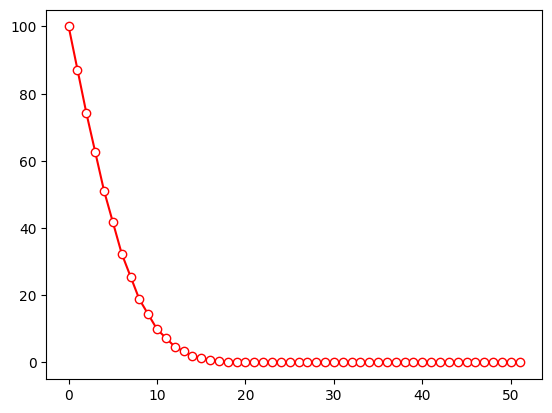

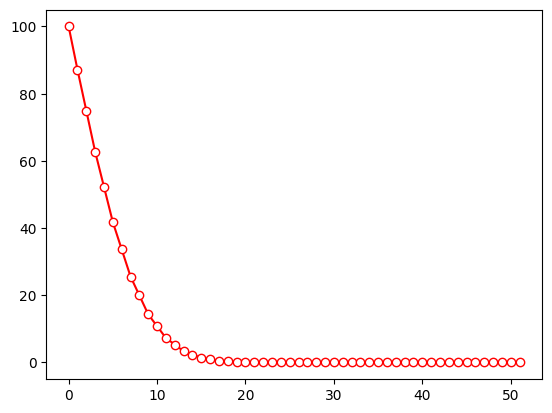

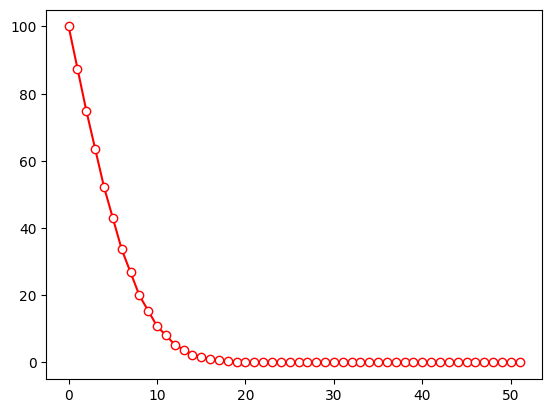

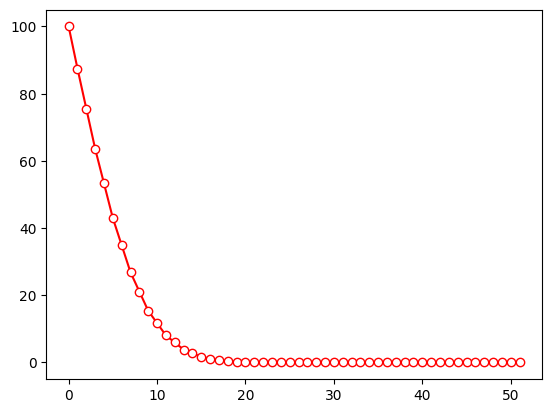

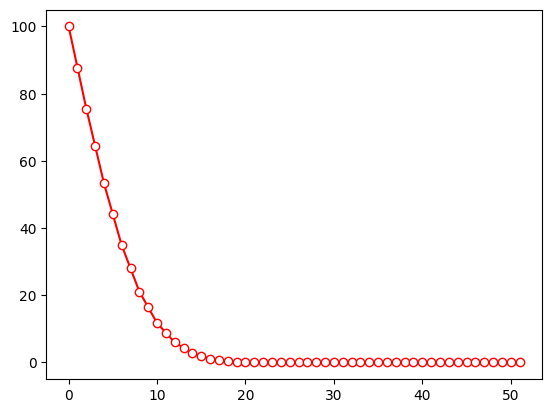

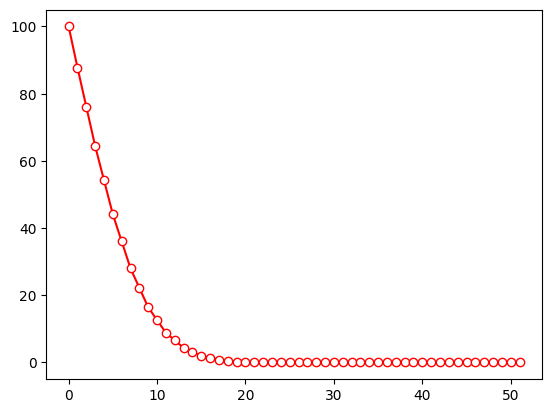

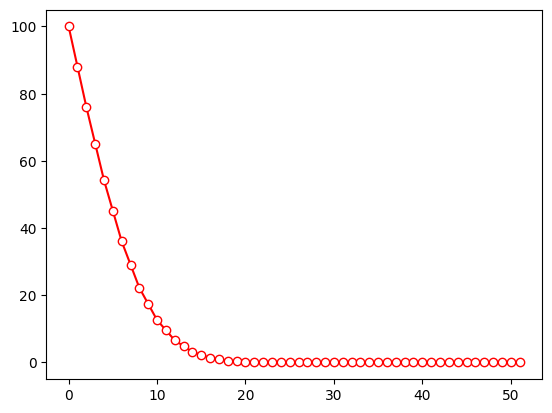

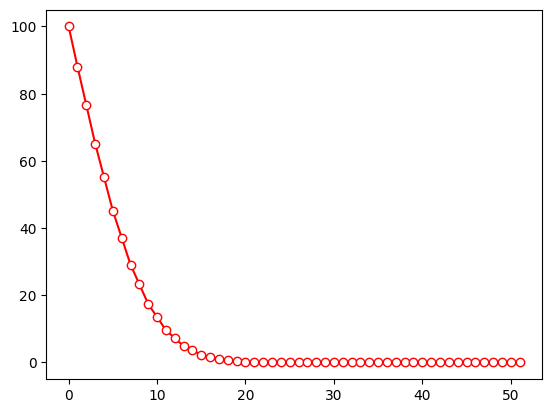

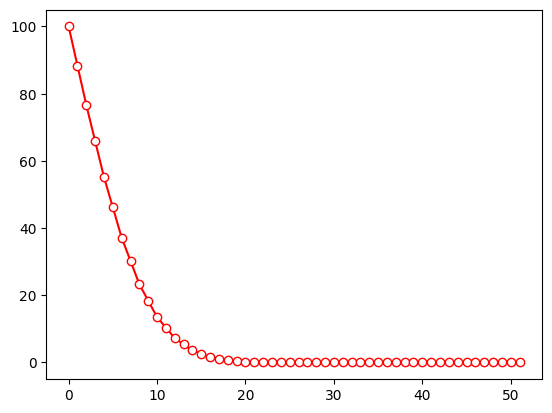

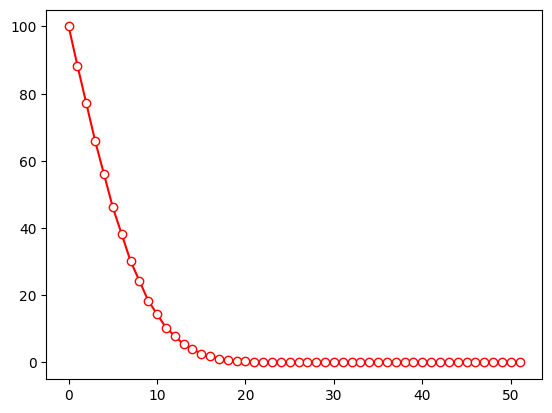

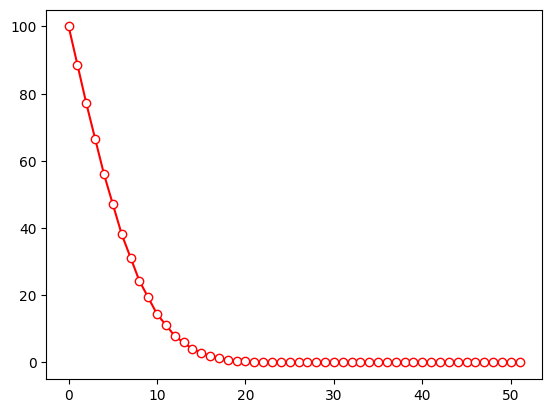

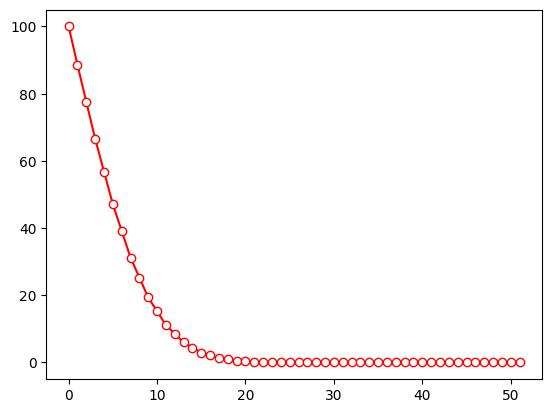

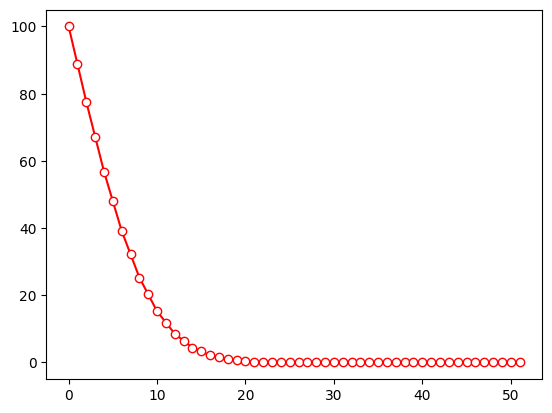

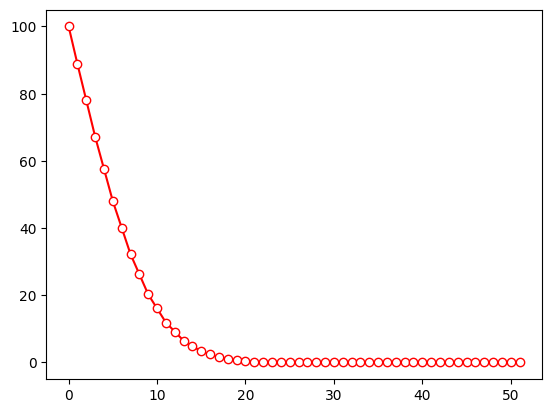

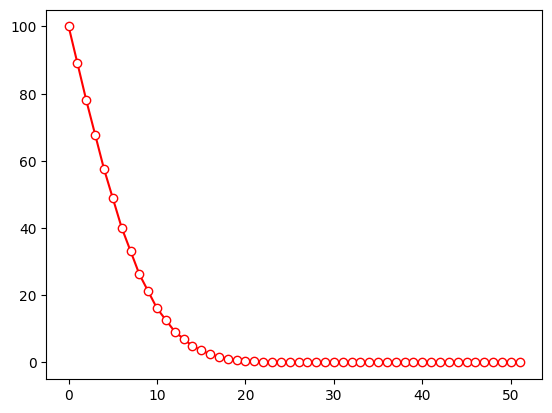

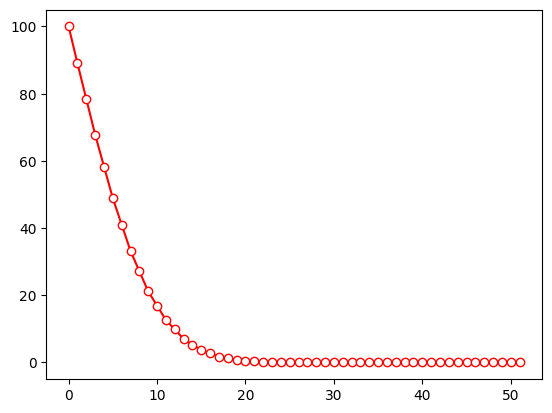

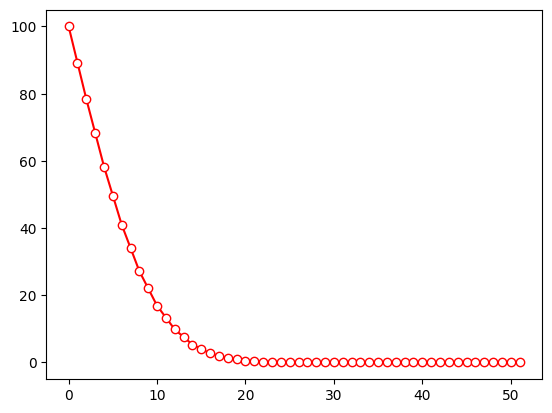

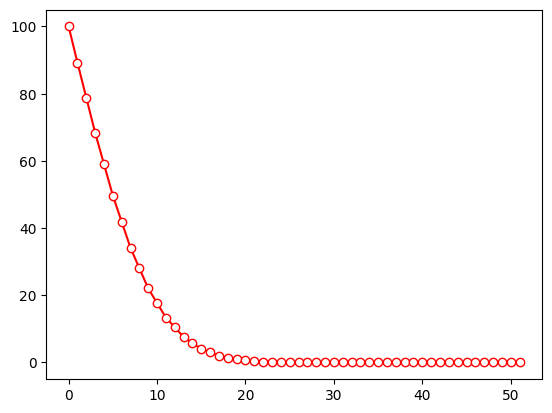

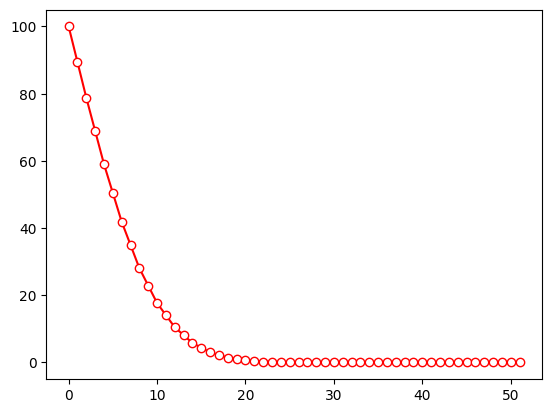

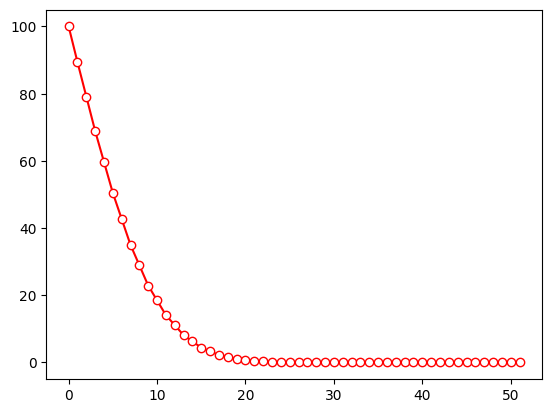

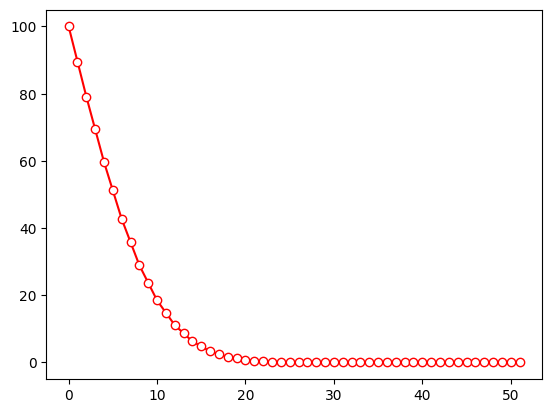

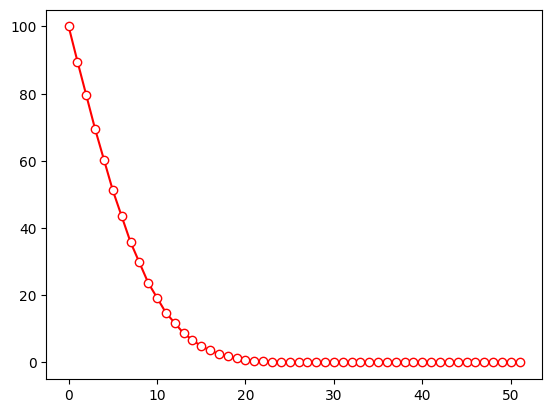

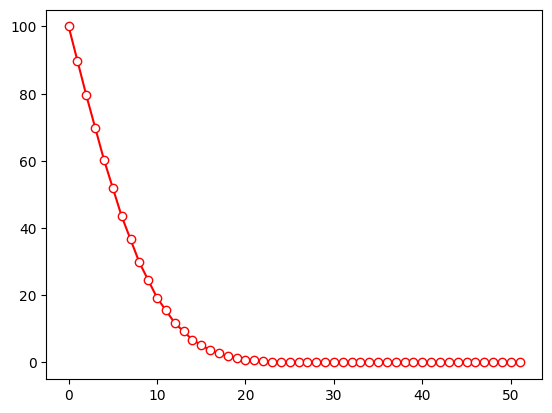

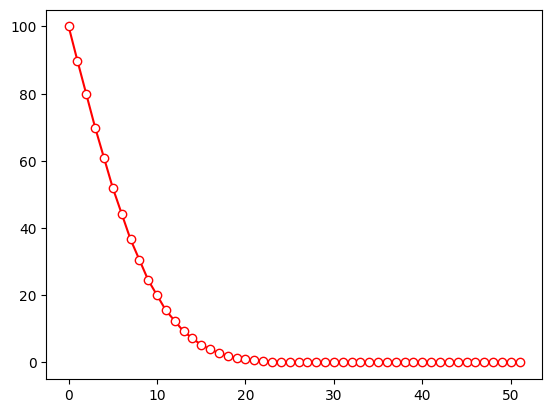

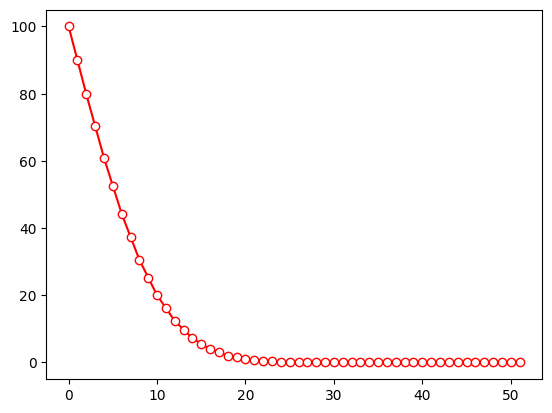

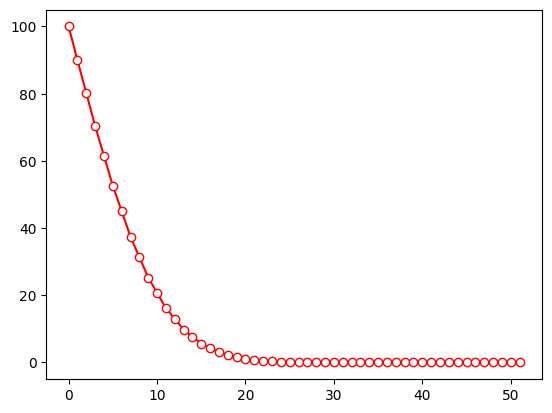

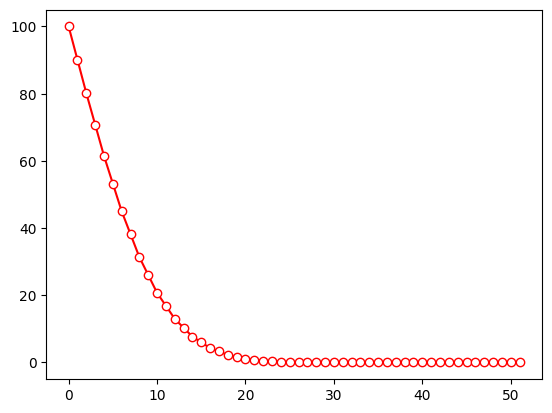

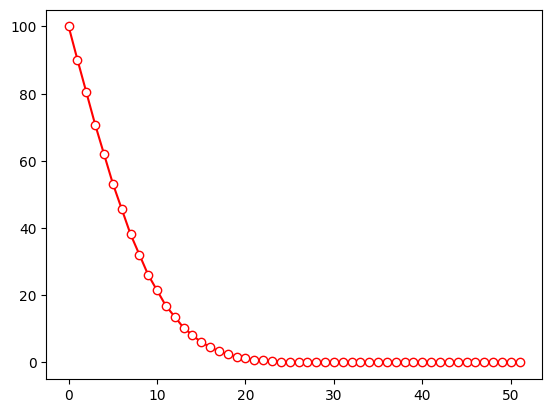

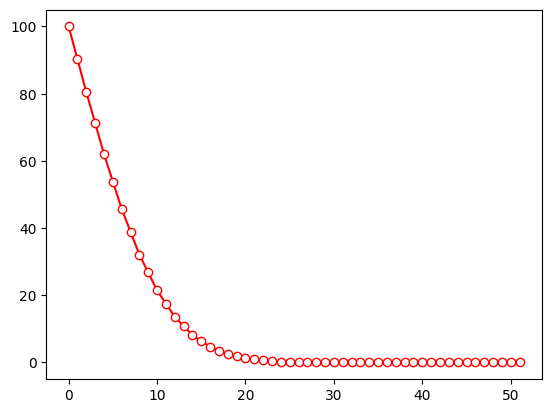

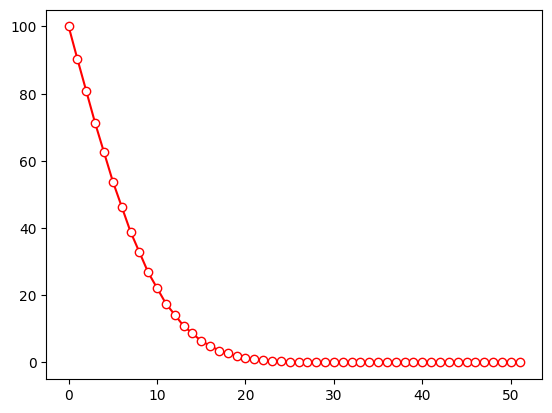

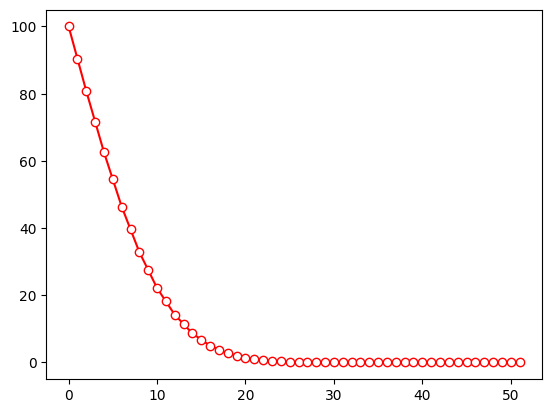

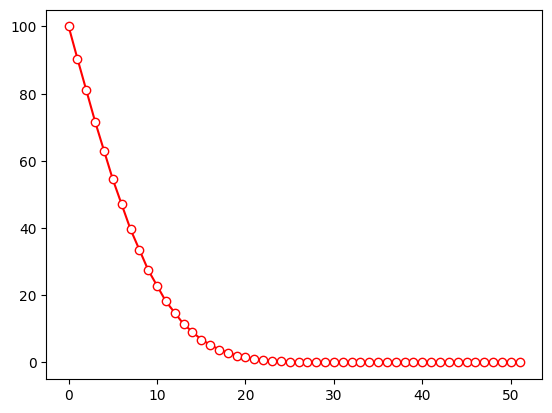

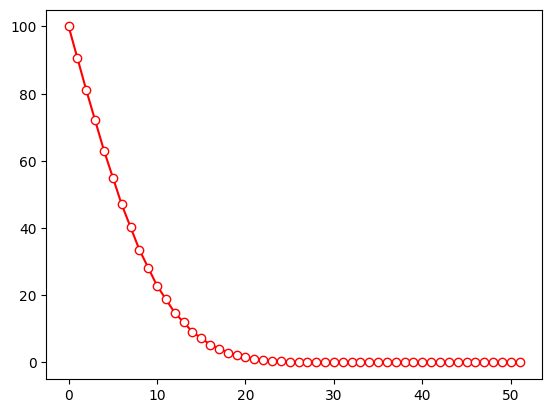

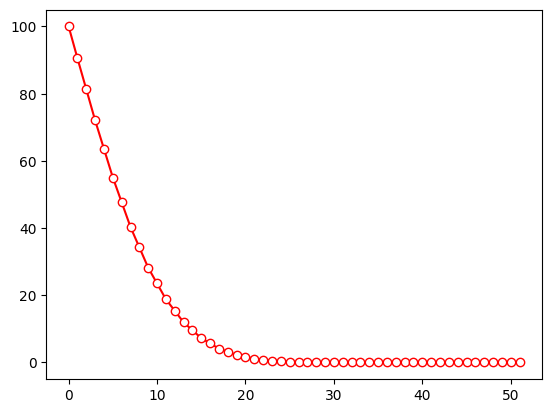

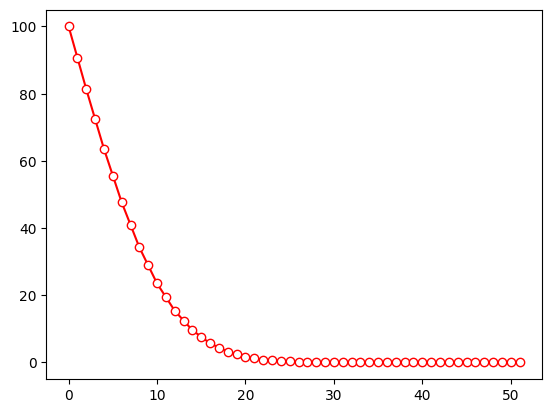

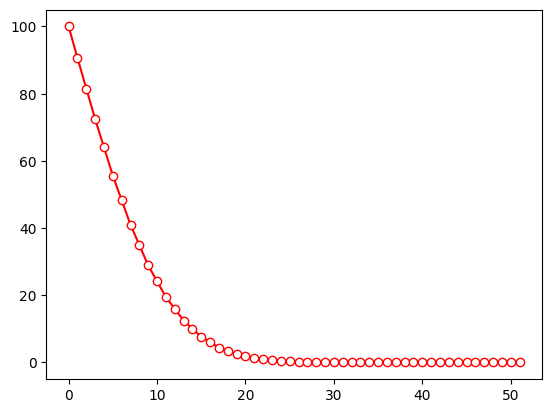

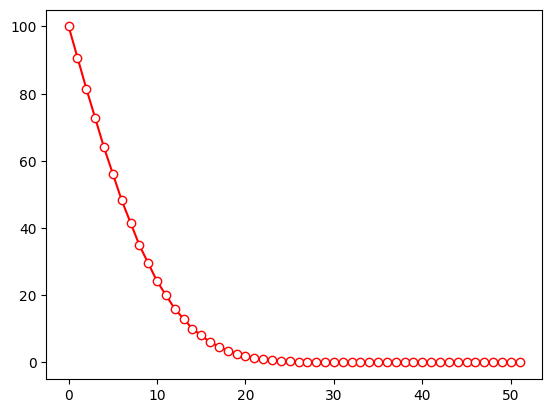

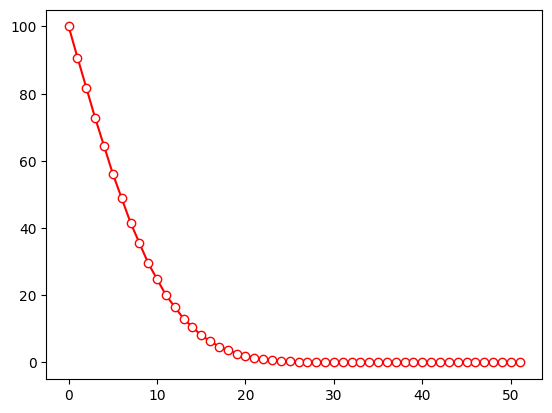

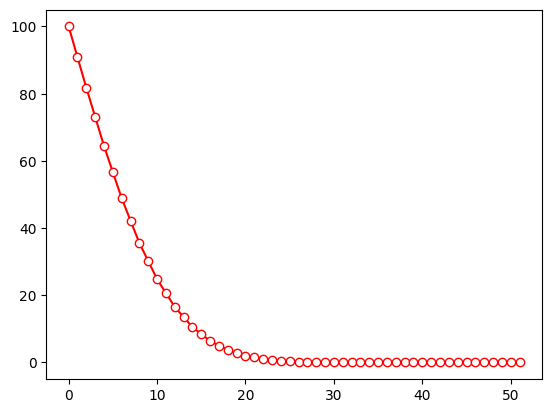

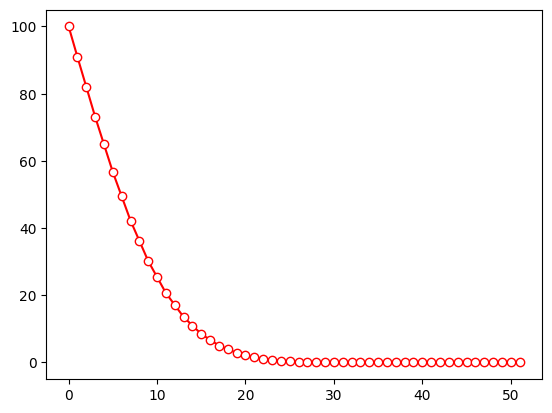

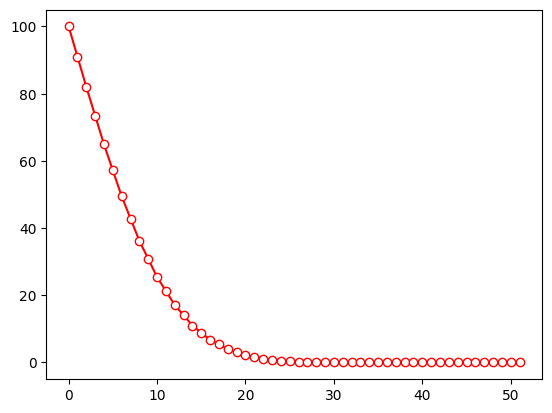

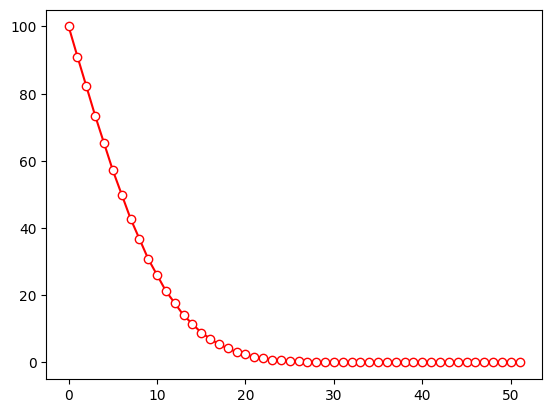

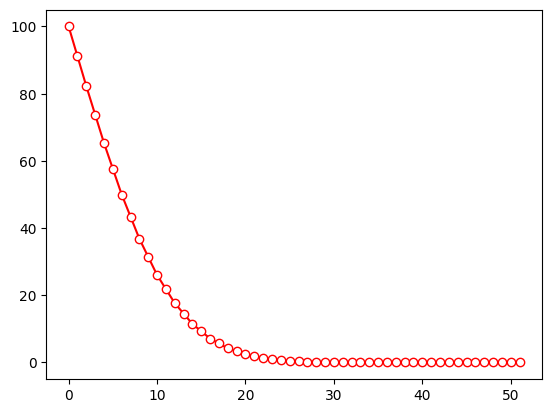

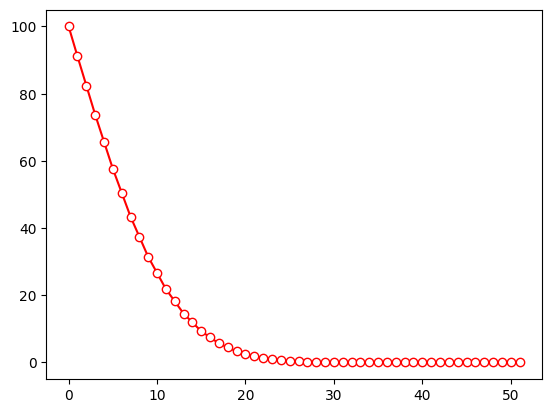

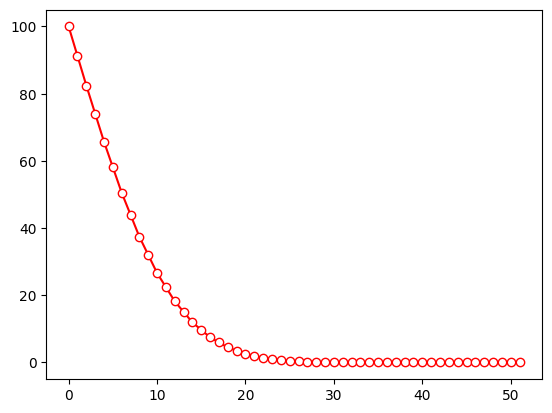

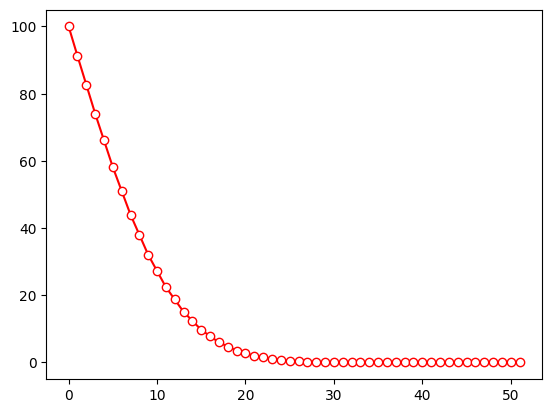

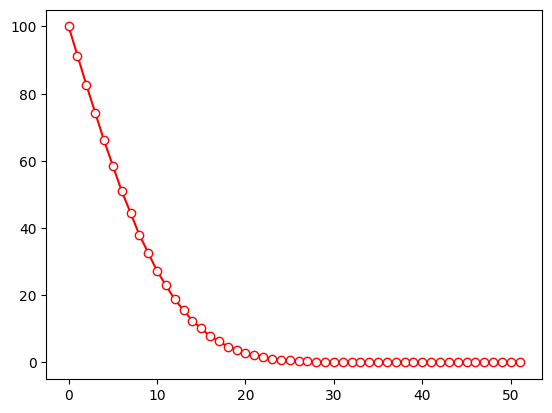

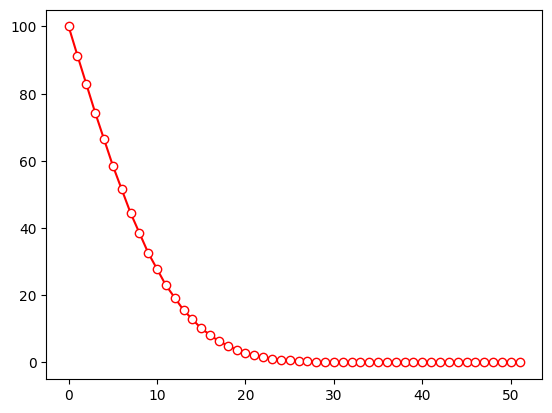

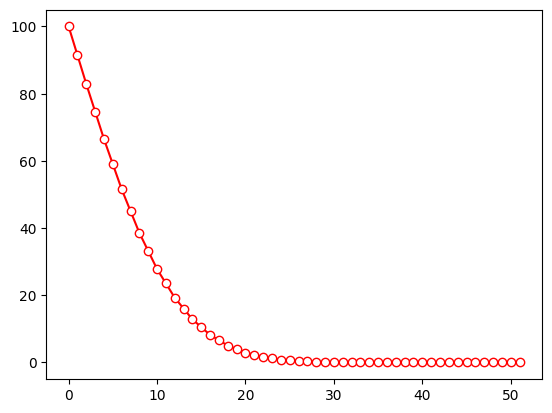

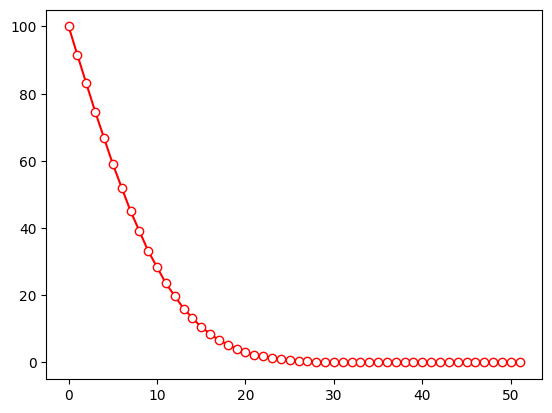

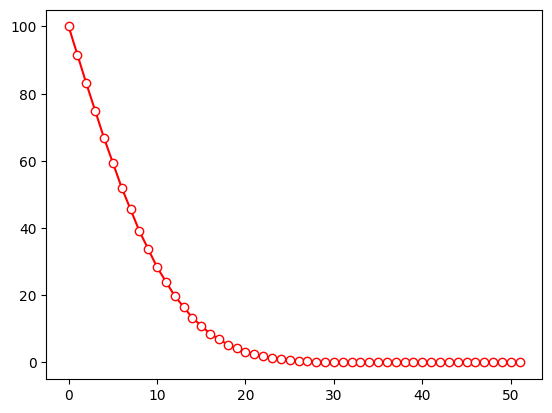

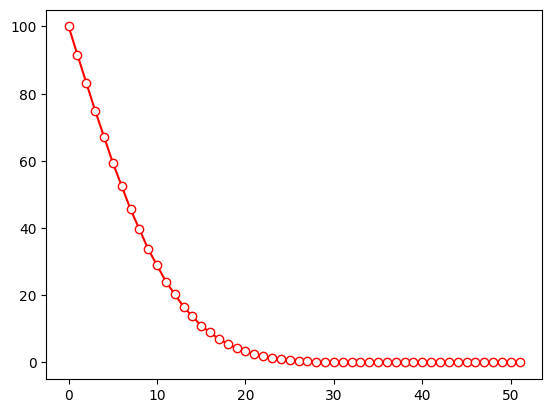

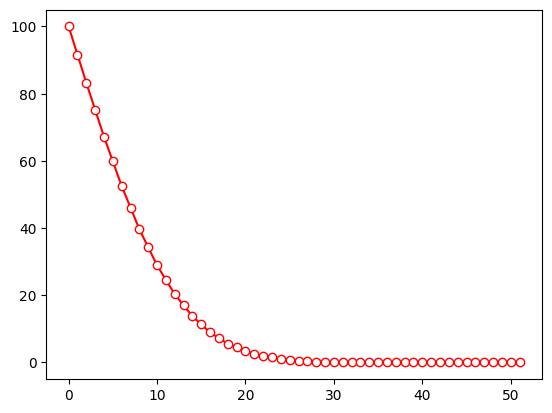

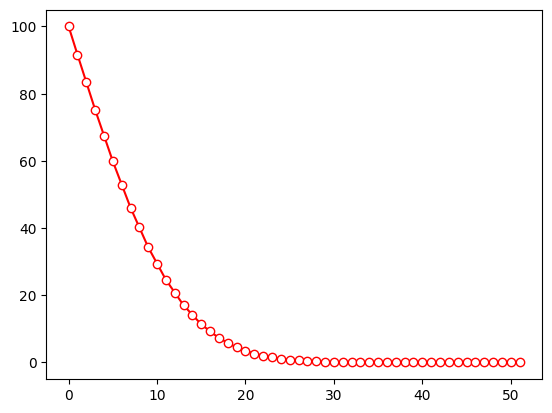

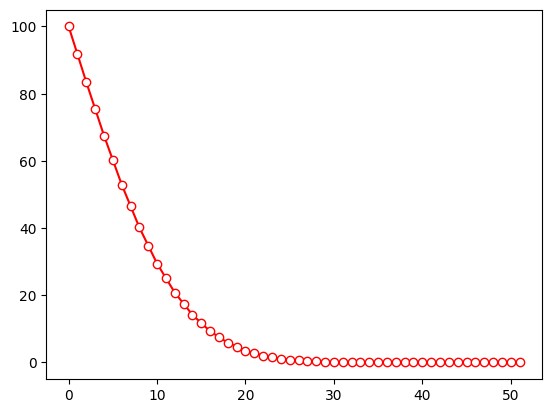

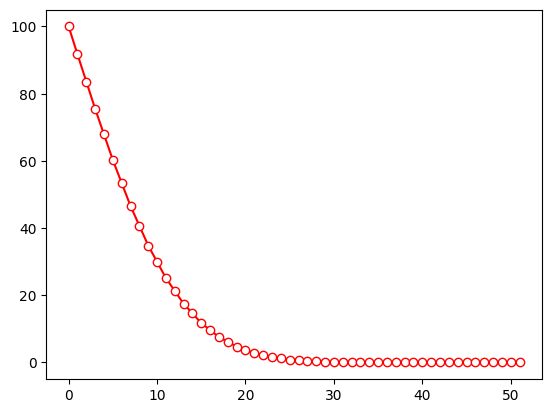

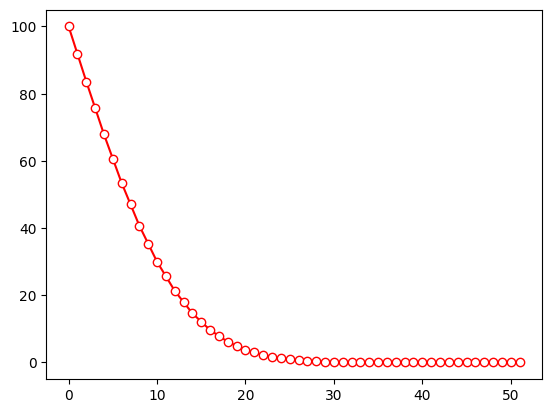

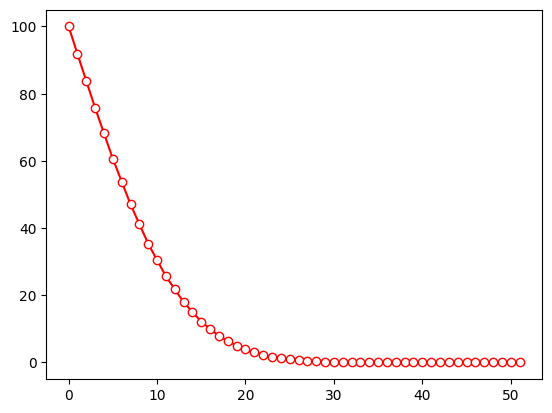

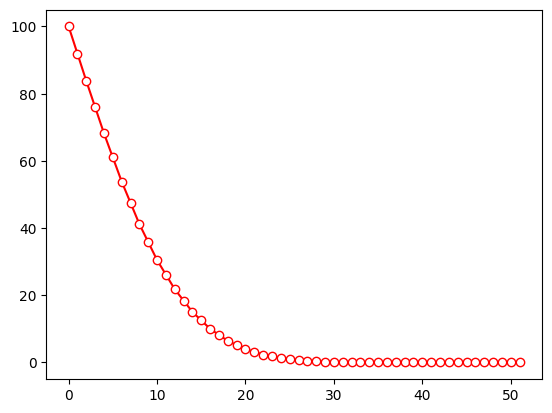

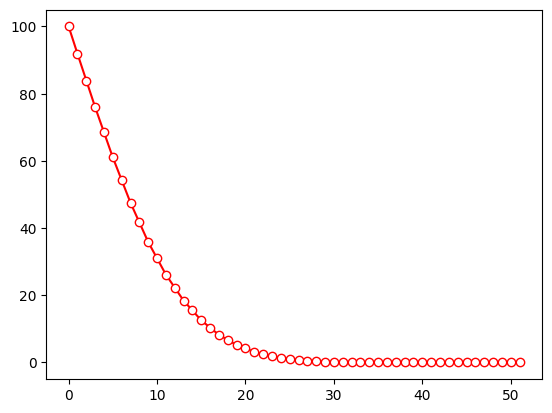

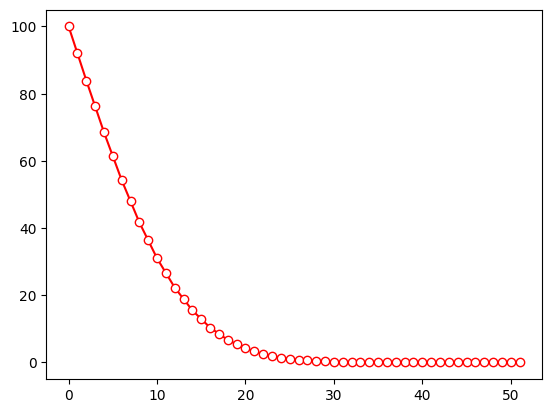

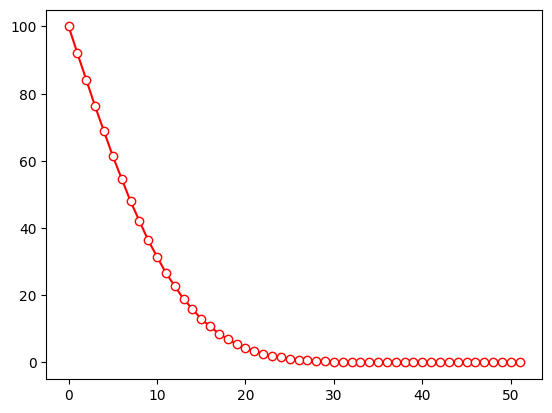

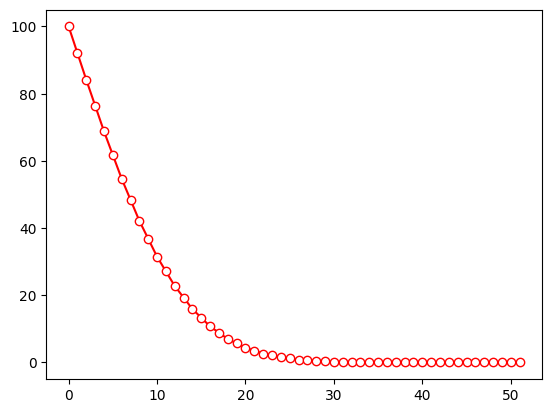

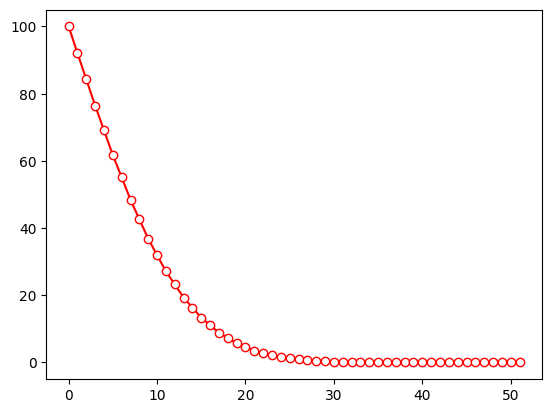

In [3]:
N=51
T=np.zeros(N+1)
T[0]=100
T[N]=0
Tnew=np.copy(T)
for k in range(100):
  for j in range(1,N):
    Tnew[j] = 0.5*(T[j-1]+T[j+1])
  T=np.copy(Tnew)
  plt.clf()
  plt.plot(T, 'ro-', mfc= 'w')
  plt.show()

Stationary State of the 1D heat equation

Discretize the interval x=[0,L] in N sections using N+1 equally spaced points in order to solve the
1D heat equation with the boundary conditions T(x=0)=100 and T(x=L)=0 and the initial condition
T(x>0)=0. Please note that Python only understands the notation T[i] but not T(x=0), T(x=L), and
T(x>0).

(1) N=51 and L=30 are good values to start but your code
should work for any N and L. First you need to decide
which index i corresponds to point x=0 and which index
corresponds to x=L. Then write two lines to code to set
up a vector T to represent the specified initial conditions.

In [ ]:
N=51 # jumlah interval (jumblah bunder2)
L=30 # panjang sumbu x
step = L/N # jarak antar titik -> 0.588
x=np.arange(0, L+step, step) # buat koordinat (bunder-bunder)
# Get 0, L/N, 2L/N_ L(N-1)/N. So N points?
T=np.zeros(N+1) # Tinggi (suhu) bunder2 scr vertikal -> N+1 brrti isi 52 titik
T[0] = 100 # Boundary condition di ujung kiri (x=0) sebesar 100 derajat
T[N] = 0 # Boundary condition di ujung kanan (x=L) sebesar 0 derajat

In [ ]:
print(T.shape)
print(T)

(52,)
[100.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]


(2) Write the main, outer loop over different iterations to obtain the stationary state of the 1D heat
equation. Please refer to lecture 12 on PDEs slide 25 and following if something is unclear.) Inside
the main loop introduce a inner loop to update every temperature in the interior of the interval
[0,L]. The update formula in the Jacobi method is Tinew = 1/2 [Ti-1 + Ti+1]

(3) Before entering the inner loop introduce a second temperature vector Tnew. Choose the correct
command from the following three options: Tnew=T and Tnew=np.copy(T) and Tnew[:]=T[:]. Then
update the interior points of Tnew according to (*) and copy the results in Tnew back to T so that
they are the starting temperatures for the next iteration.

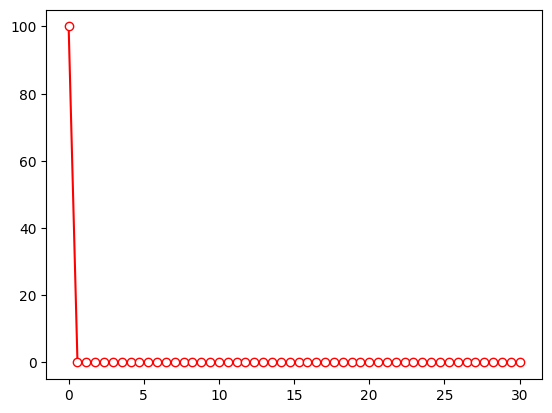

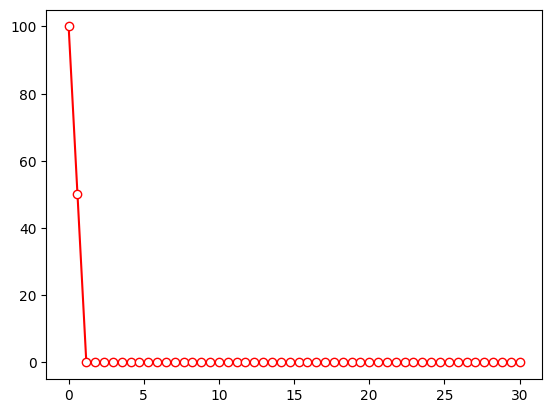

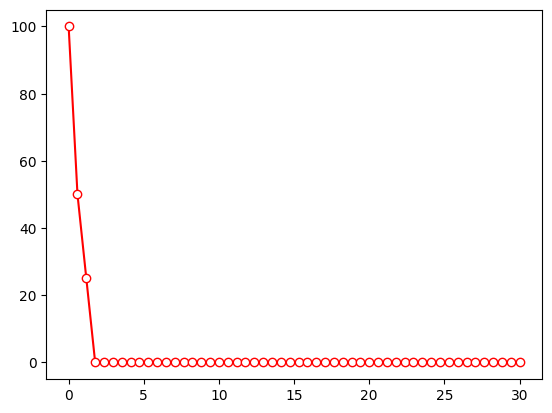

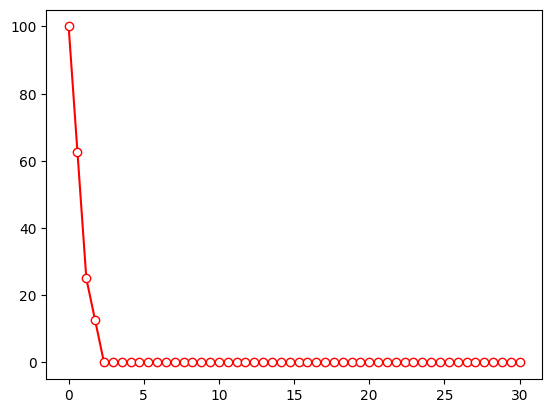

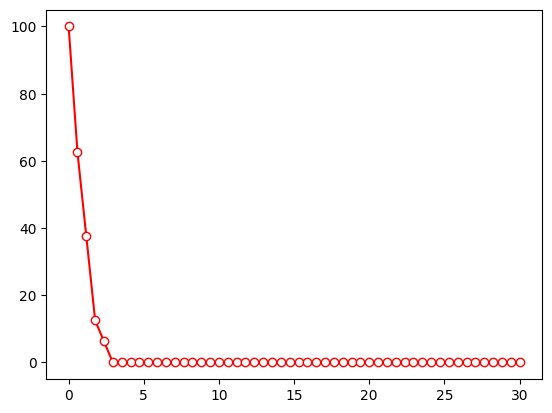

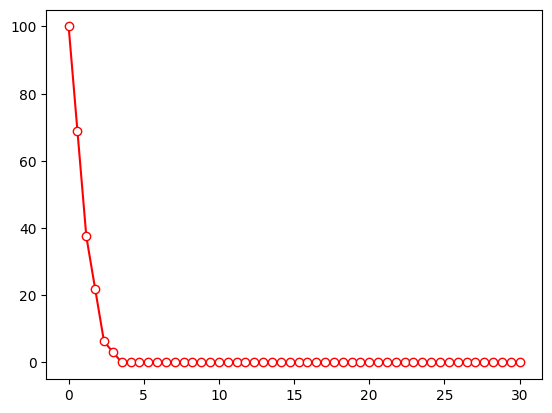

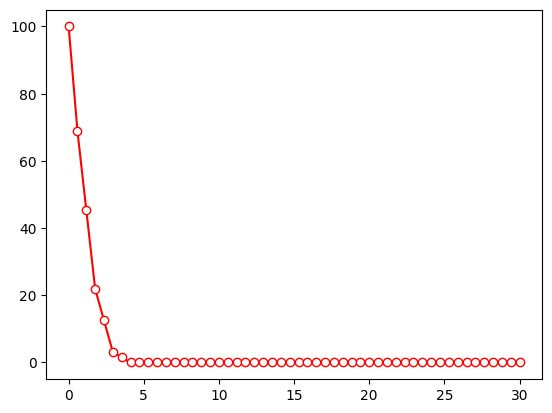

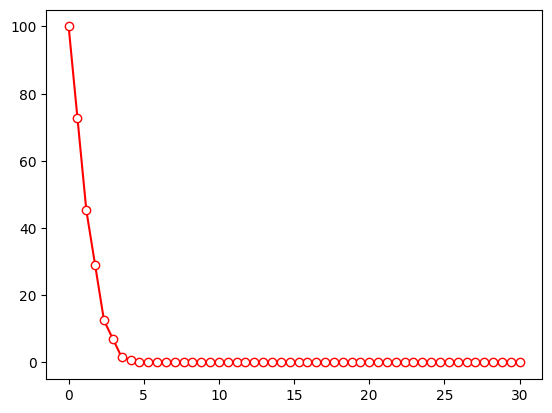

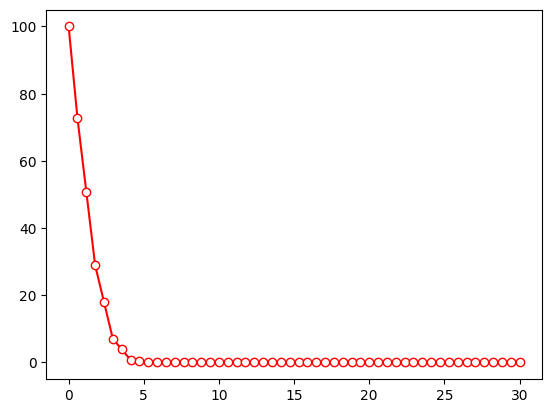

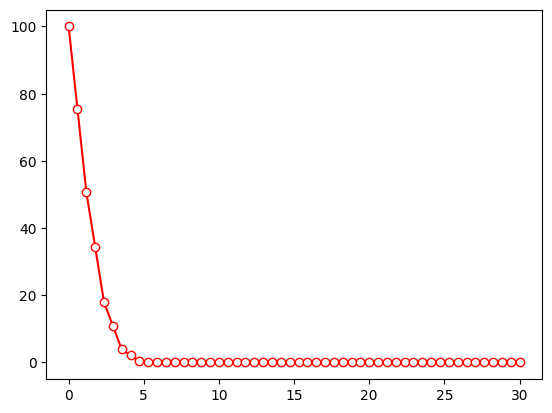

<Figure size 640x480 with 0 Axes>

In [ ]:
n=10 # outer loop: 10x (dari 0-9)
for i in range(0, n): # Setiap iterasi mewakili satu langkah waktu di mana panas merambat sedikit demi sedikit.
  plt.clf() # membersihkan grafik lama agar tidak menumpuk.
  plt.plot(x, T, 'ro-', mfc='w') # menggambar titik-titik (bunder2) suhu saat ini.
  plt.show() # menampilkan gambar ke layar
  plt.draw() # memperbarui atau menggambar ulang figur -> mastiin grafik ke render
  # plt.pause(0.05)
  Tnew=np.copy(T) # buat salinan suhu saat ini
  for j in range(1, N): # inner loop, hitung ulang suhu untuk setiap titik di bagian tengah batang (indeks 1 sampai 50)
      Tnew[j] = 0.5 * (T[j - 1] + T[j + 1]) # update Tnew -> suhu di suatu titik (j) adalah rata2 dari suhu tetangga kiri dan kanannya
  T = np.copy(Tnew) # assign nilai T dengan Tnew yang baru selesai di update

Same logic, but for video generation purpose

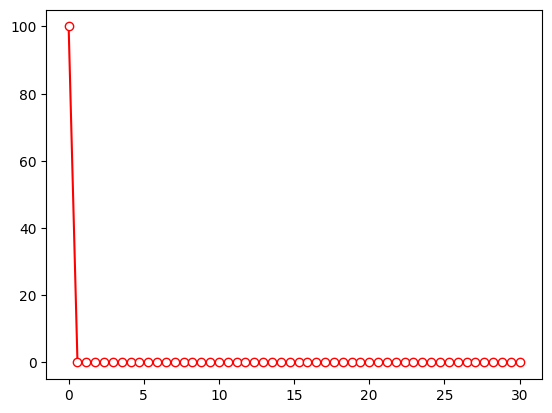

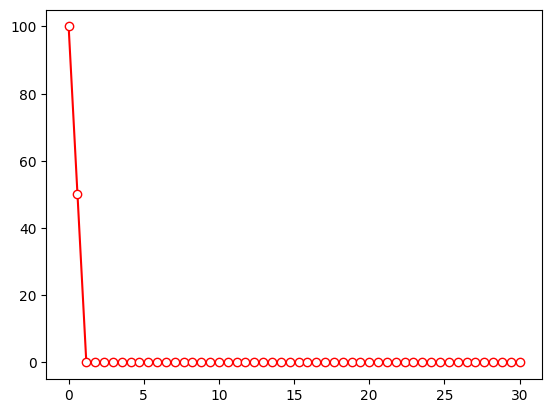

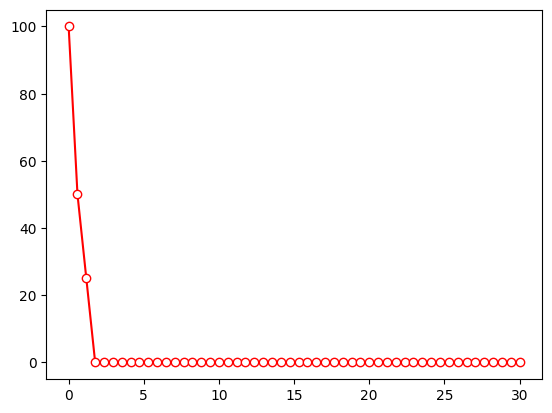

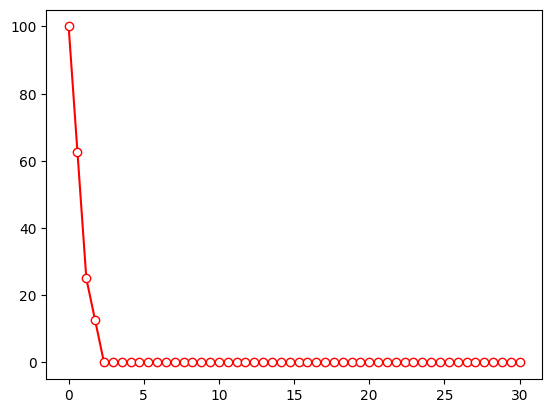

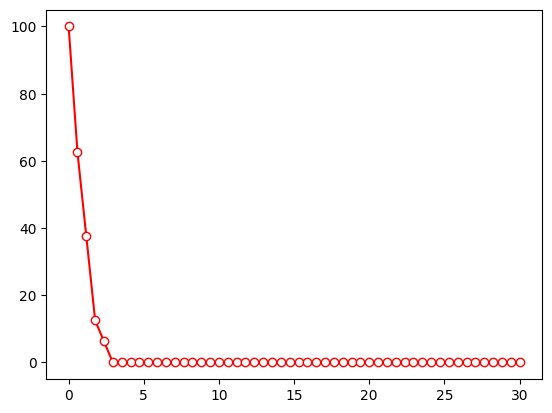

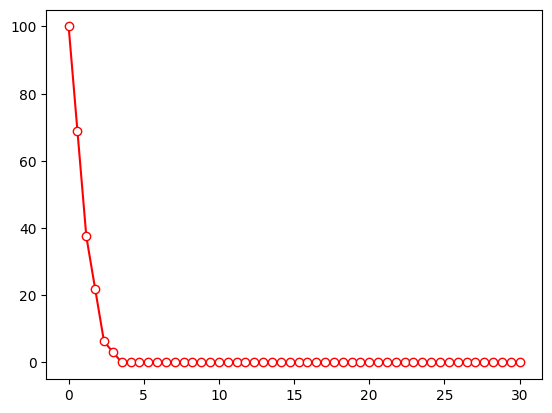

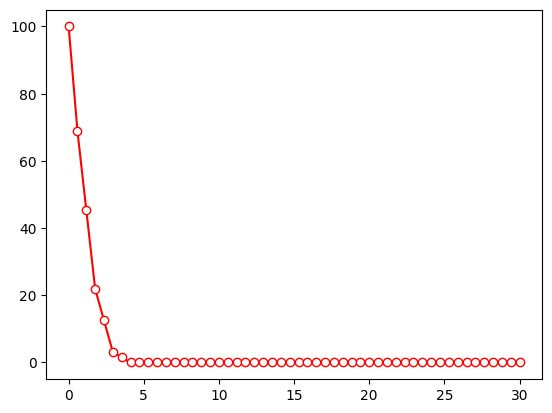

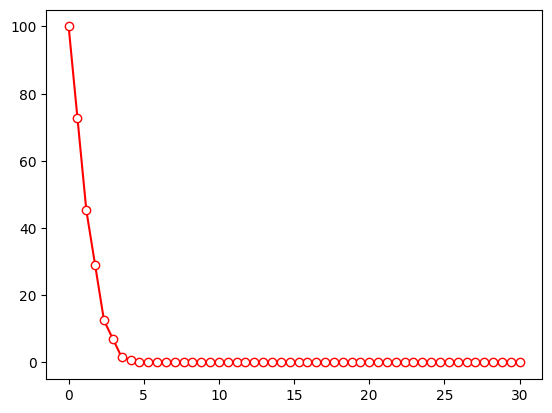

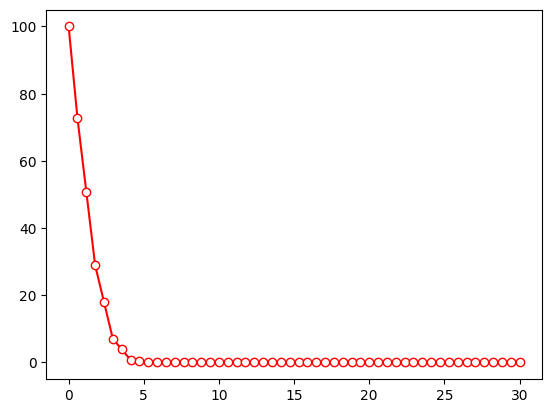

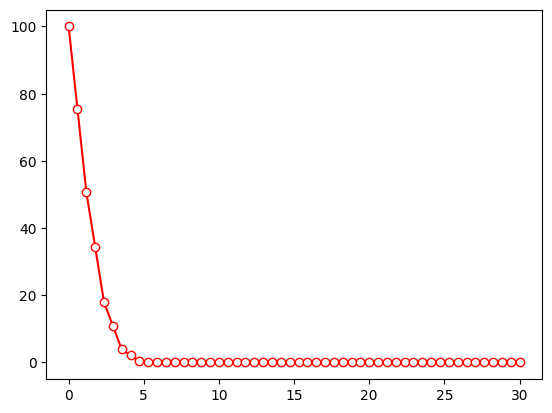

Simulation finished. 10 frames saved.


In [ ]:
import os

# Create a directory to store frames
frames_dir = 'heat_equation_frames'
os.makedirs(frames_dir, exist_ok=True)

n = 10
for i in range(0, n):
    # Create a figure with explicit size to ensure consistency
    fig = plt.figure(figsize=(8, 5), dpi=100)
    plt.plot(x, T, 'ro-', mfc='w')
    plt.title(f'Iteration {i}')
    plt.xlabel('Distance L')
    plt.ylabel('Temperature T')
    plt.ylim(-10, 110)

    # SAVE FIRST: using the specific figure object and matching DPI
    frame_path = os.path.join(frames_dir, f'frame_{i:04d}.png')
    plt.savefig(frame_path, dpi=100)

    # Then display it
    plt.show()

    # Your original update logic (Jacobi method)
    Tnew = np.copy(T)
    for j in range(1, N):
        Tnew[j] = 0.5 * (T[j - 1] + T[j + 1])
    T = np.copy(Tnew)

print(f"Simulation finished. {len(os.listdir(frames_dir))} frames saved.")

In [ ]:
import os
import imageio.v2 as iio

frames_dir = 'heat_equation_frames'
output_video_path = 'heat_equation_simulation.mp4'

if os.path.exists(frames_dir):
    filenames = sorted([os.path.join(frames_dir, f) for f in os.listdir(frames_dir) if f.endswith('.png')],
                       key=lambda x: int(''.join(filter(str.isdigit, x)) or 0))

    if filenames:
        print(f"Creating video at 2 fps to make it look slower...")
        # Changed fps from 10 to 2 to slow down the playback
        with iio.get_writer(output_video_path, fps=2) as writer:
            for filename in filenames:
                image = iio.imread(filename)
                writer.append_data(image)
        print("Video created successfully!")

Creating video at 2 fps to make it look slower...
Video created successfully!


In [ ]:
# Clean up the individual image frames after video generation
import shutil

if os.path.exists(output_video_path):
    if os.path.exists(frames_dir):
        shutil.rmtree(frames_dir)
        print(f"Cleaned up temporary directory: '{frames_dir}'")
    else:
        print("Temporary frames directory already removed.")
else:
    print("Video not found; skipping directory cleanup to preserve frames.")

Cleaned up temporary directory: 'heat_equation_frames'
